# 1. Configuración inicial


In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

# Configuración para visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 2. Cargar y explorar los datos


In [2]:
# Crear datos sintéticos similares al ejemplo del blog
np.random.seed(42)
n_samples = 500

# Generar características similares a las del ejemplo original
data = {
    'ingresos': np.random.normal(50000, 15000, n_samples),
    'gastos_comunes': np.random.normal(1200, 300, n_samples),
    'pago_coche': np.random.normal(800, 200, n_samples),
    'pago_otros': np.random.normal(1000, 250, n_samples),
    'ahorros': np.random.normal(30000, 10000, n_samples),
    'vivienda': np.random.normal(250000, 50000, n_samples),
    'estado_civil': np.random.randint(0, 2, n_samples),  # 0: soltero, 1: casado
    'hijos': np.random.randint(0, 3, n_samples),  # 0, 1 o 2 hijos
    'trabajo': np.random.randint(0, 3, n_samples)  # 0: temporal, 1: estable, 2: alto
}

# Crear la variable objetivo 'comprar' basada en combinación de características
# Esta es la variable que queremos predecir en el ejemplo original
df = pd.DataFrame(data)

# Crear variable objetivo (similar al ejemplo del blog)
# En el ejemplo original: 0 = Alquilar, 1 = Comprar
df['comprar'] = np.where(
    (df['ingresos'] > 45000) &
    (df['ahorros'] > 20000) &
    (df['vivienda'] < 300000) &
    (df['estado_civil'] == 1),
    1,  # Comprar
    0   # Alquilar
)

# Añadir algo de ruido para hacerlo más realista
noise = np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15])
df['comprar'] = np.where(noise == 1, 1 - df['comprar'], df['comprar'])

print("Datos sintéticos creados exitosamente")
print(f"Forma del dataset: {df.shape}")
print(f"Distribución de la variable 'comprar':")
print(df['comprar'].value_counts())
print(f"0: Alquilar ({df['comprar'].value_counts()[0]} muestras)")
print(f"1: Comprar ({df['comprar'].value_counts()[1]} muestras)")

# Mostrar primeras filas
print("\nPrimeras 5 filas del dataset:")
print(df.head())

Datos sintéticos creados exitosamente
Forma del dataset: (500, 10)
Distribución de la variable 'comprar':
comprar
0    349
1    151
Name: count, dtype: int64
0: Alquilar (349 muestras)
1: Comprar (151 muestras)

Primeras 5 filas del dataset:
       ingresos  gastos_comunes   pago_coche   pago_otros       ahorros  \
0  57450.712295     1477.853264  1079.871087  1194.590269  23248.217250   
1  47926.035482     1772.824992   984.926737   862.203571  28554.813293   
2  59715.328072      780.429728   811.926074   795.450279  22075.800790   
3  72845.447846     1368.890771   670.612644   999.156386  26920.384704   
4  46487.699379     1004.807229   939.644663   957.453844  11063.853330   

        vivienda  estado_civil  hijos  trabajo  comprar  
0  278530.649861             1      0        0        1  
1  298409.233027             1      2        0        1  
2  233434.580841             1      2        2        1  
3  219388.163275             1      0        2        1  
4  195742.473672 

# 3. Preparación de los datos

In [3]:
# Separar características y variable objetivo
X = df.drop('comprar', axis=1)  # Características
y = df['comprar']  # Variable objetivo

print(f"Número de características originales: {X.shape[1]}")

# Estandarizar los datos (PASO 1 según el blog)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nDatos estandarizados (primeras 5 filas):")
print(X_scaled[:5, :])

Número de características originales: 9

Datos estandarizados (primeras 5 filas):
[[ 0.49973518  0.91538823  1.27905805  0.75799726 -0.69231973  0.54393041
   0.99203175 -1.28170603 -1.22938611]
 [-0.14802256  1.92175493  0.80868051 -0.59443049 -0.13874553  0.93896179
   0.99203175  1.18311326 -1.22938611]
 [ 0.65374801 -1.4640392  -0.04840709 -0.86603885 -0.81462402 -0.35222814
   0.99203175  1.18311326  1.18591077]
 [ 1.54670605  0.54363659 -0.74850839 -0.03719163 -0.30924607 -0.6313615
   0.99203175 -1.28170603  1.18591077]
 [-0.24584145 -0.69852162  0.58434204 -0.20687253 -1.96336983 -1.10125361
  -1.00803226  1.18311326  1.18591077]]


# 4. Aplicar PCA

In [4]:
# Aplicar PCA (PASO 2 según el blog)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("PCA aplicado exitosamente")
print(f"Forma de los datos transformados: {X_pca.shape}")

PCA aplicado exitosamente
Forma de los datos transformados: (500, 9)


# 5. Análisis de la varianza explicada

In [5]:
# Calcular la varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Crear tabla de varianza explicada
print("Varianza explicada por cada componente principal:")
print("=" * 60)
for i, (var_individual, var_acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"Componente {i+1}: {var_individual*100:.2f}% | Acumulado: {var_acum*100:.2f}%")
print("=" * 60)

# Determinar cuántos componentes necesitamos para alcanzar el 85% de varianza explicada
# (Método 2 mencionado en el blog)
n_componentes_85 = np.argmax(varianza_acumulada >= 0.85) + 1
print(f"\nNúmero de componentes para explicar al menos el 85% de varianza: {n_componentes_85}")

Varianza explicada por cada componente principal:
Componente 1: 13.73% | Acumulado: 13.73%
Componente 2: 12.72% | Acumulado: 26.46%
Componente 3: 12.09% | Acumulado: 38.55%
Componente 4: 11.52% | Acumulado: 50.07%
Componente 5: 11.08% | Acumulado: 61.15%
Componente 6: 10.47% | Acumulado: 71.62%
Componente 7: 9.92% | Acumulado: 81.54%
Componente 8: 9.59% | Acumulado: 91.13%
Componente 9: 8.87% | Acumulado: 100.00%

Número de componentes para explicar al menos el 85% de varianza: 8


# 6. Visualizaciones

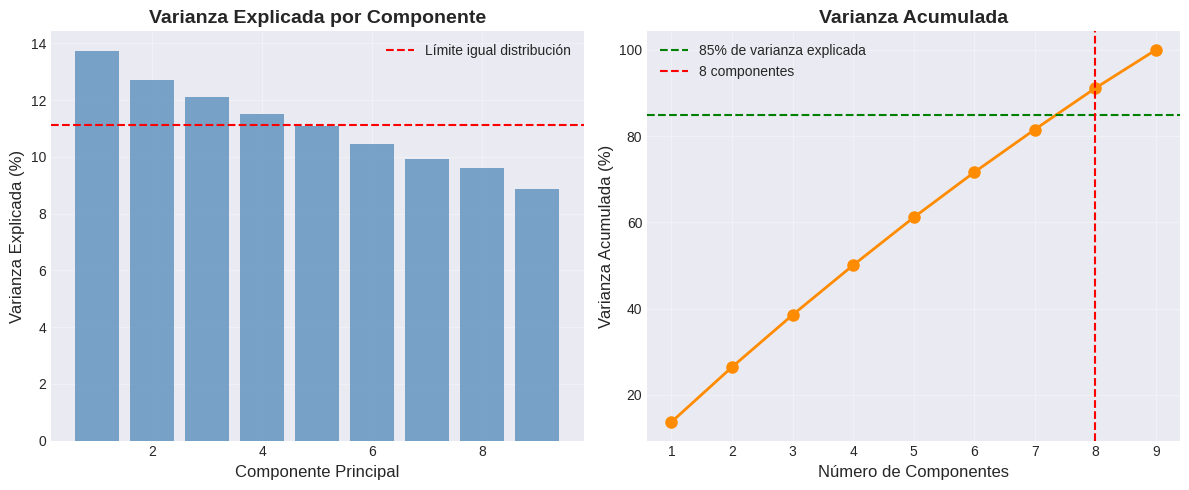

In [6]:
# Gráfica 1: Varianza explicada acumulada (Método 2 del blog)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada * 100,
        alpha=0.7, color='steelblue')
plt.xlabel('Componente Principal', fontsize=12)
plt.ylabel('Varianza Explicada (%)', fontsize=12)
plt.title('Varianza Explicada por Componente', fontsize=14, fontweight='bold')
plt.axhline(y=100/len(varianza_explicada), color='r', linestyle='--',
            label='Límite igual distribución')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada * 100,
         'o-', linewidth=2, markersize=8, color='darkorange')
plt.axhline(y=85, color='green', linestyle='--', linewidth=1.5,
            label='85% de varianza explicada')
plt.axvline(x=n_componentes_85, color='red', linestyle='--', linewidth=1.5,
            label=f'{n_componentes_85} componentes')
plt.xlabel('Número de Componentes', fontsize=12)
plt.ylabel('Varianza Acumulada (%)', fontsize=12)
plt.title('Varianza Acumulada', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

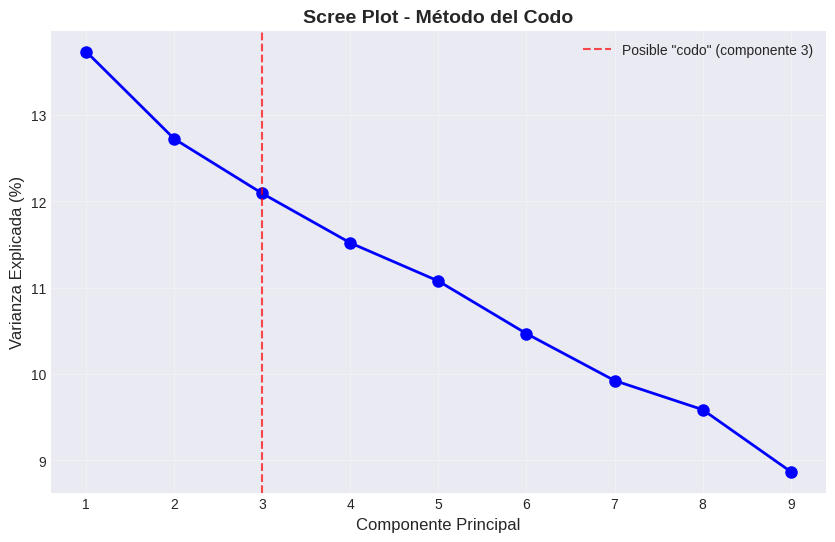

In [7]:
# Gráfica 2: Scree Plot (Método 3 del blog)
plt.figure(figsize=(10, 6))

# Calcular la varianza explicada por componente como en el ejemplo del blog
componentes = range(1, len(varianza_explicada) + 1)

plt.plot(componentes, varianza_explicada * 100, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Componente Principal', fontsize=12)
plt.ylabel('Varianza Explicada (%)', fontsize=12)
plt.title('Scree Plot - Método del Codo', fontsize=14, fontweight='bold')

# Resaltar el "codo" en la gráfica (aproximadamente en el componente 3)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7,
            label='Posible "codo" (componente 3)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

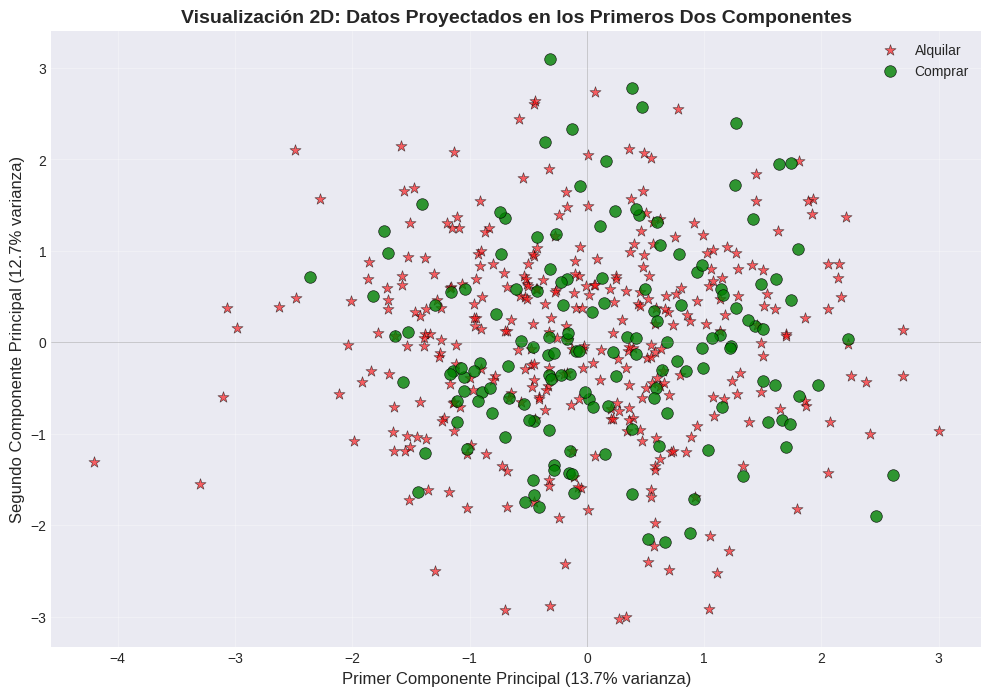

In [8]:
# Gráfica 3: Visualización 2D con los dos primeros componentes principales
# (Similar a la visualización del blog)

# Preparar datos para la gráfica
Xax = X_pca[:, 0]  # Primer componente principal
Yax = X_pca[:, 1]  # Segundo componente principal

# Configurar colores y etiquetas como en el ejemplo del blog
labels = y.values
cdict = {0: 'red', 1: 'green'}
labl = {0: 'Alquilar', 1: 'Comprar'}
marker = {0: '*', 1: 'o'}
alpha = {0: 0.6, 1: 0.8}

# Crear la gráfica
plt.figure(figsize=(12, 8))

for l in np.unique(labels):
    ix = np.where(labels == l)
    plt.scatter(Xax[ix], Yax[ix],
                c=cdict[l],
                label=labl[l],
                s=70,
                marker=marker[l],
                alpha=alpha[l],
                edgecolors='black',
                linewidth=0.5)

plt.xlabel(f"Primer Componente Principal ({varianza_explicada[0]*100:.1f}% varianza)",
           fontsize=12)
plt.ylabel(f"Segundo Componente Principal ({varianza_explicada[1]*100:.1f}% varianza)",
           fontsize=12)
plt.title("Visualización 2D: Datos Proyectados en los Primeros Dos Componentes",
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Añadir líneas en los ejes
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

plt.show()

# 7. Interpretación de los componentes principales


In [9]:
# Analizar las cargas de los componentes principales (cómo se relacionan con las características originales)
print("Pesos (cargas) de las características originales en los primeros 3 componentes principales:")
print("=" * 80)

# Crear un DataFrame para visualizar las cargas
componentes_df = pd.DataFrame(
    pca.components_.T[:, :3],  # Transponer para tener características como filas
    columns=[f'PC{i+1}' for i in range(3)],
    index=X.columns
)

# Mostrar las cargas
print(componentes_df)

# Identificar las características más importantes para cada componente principal
print("\nCaracterísticas más importantes para cada componente principal:")
print("=" * 80)

for i in range(3):
    # Obtener las 3 características con mayor peso absoluto en este componente
    top_features = componentes_df.abs().nlargest(3, f'PC{i+1}').index.tolist()
    print(f"Componente {i+1}: {', '.join(top_features)}")

print("\nInterpretación según el blog del blog:")
print("-" * 80)
print("""Cada componente principal es una combinación lineal de todas las características originales.
Los pesos indican cómo contribuye cada característica original al componente.
Componentes con mayor varianza explicada contienen más 'información' sobre los datos.""")

Pesos (cargas) de las características originales en los primeros 3 componentes principales:
                     PC1       PC2       PC3
ingresos        0.418493 -0.253387  0.444286
gastos_comunes -0.251048  0.575769  0.124847
pago_coche     -0.064981  0.576967 -0.216134
pago_otros      0.468530  0.018086 -0.017449
ahorros        -0.356083 -0.120209  0.502574
vivienda        0.202434  0.312973  0.158442
estado_civil    0.076643  0.252676  0.403162
hijos           0.450368  0.305128  0.306335
trabajo        -0.402015 -0.041436  0.453805

Características más importantes para cada componente principal:
Componente 1: pago_otros, hijos, ingresos
Componente 2: pago_coche, gastos_comunes, vivienda
Componente 3: ahorros, trabajo, ingresos

Interpretación según el blog del blog:
--------------------------------------------------------------------------------
Cada componente principal es una combinación lineal de todas las características originales.
Los pesos indican cómo contribuye cada caract

# 8. Reducción de dimensionalidad y evaluación



Reduciendo dimensionalidad a 8 componentes principales...
Datos originales: (500, 9)
Datos reducidos: (500, 8)
Varianza total retenida: 91.13%


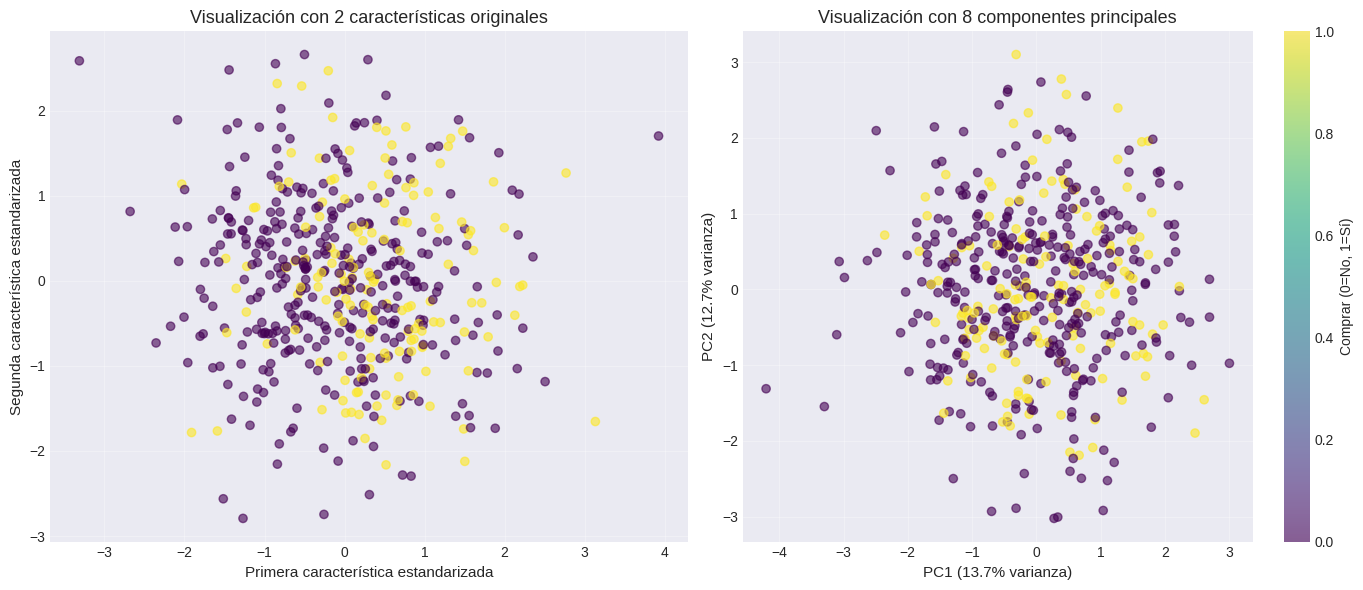

In [10]:
# Reducir a n componentes principales (según el análisis de varianza)
n_componentes = n_componentes_85  # Usamos el número para alcanzar 85% de varianza
print(f"\nReduciendo dimensionalidad a {n_componentes} componentes principales...")

# Aplicar PCA con el número seleccionado de componentes
pca_reducido = PCA(n_components=n_componentes)
X_pca_reducido = pca_reducido.fit_transform(X_scaled)

print(f"Datos originales: {X.shape}")
print(f"Datos reducidos: {X_pca_reducido.shape}")
print(f"Varianza total retenida: {pca_reducido.explained_variance_ratio_.sum()*100:.2f}%")

# Comparación visual entre datos originales y reducidos (solo para 2D)
if n_componentes >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Gráfica con datos originales (usando solo 2 características para visualización)
    axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', alpha=0.6)
    axes[0].set_xlabel('Primera característica estandarizada', fontsize=11)
    axes[0].set_ylabel('Segunda característica estandarizada', fontsize=11)
    axes[0].set_title('Visualización con 2 características originales', fontsize=13)
    axes[0].grid(True, alpha=0.3)

    # Gráfica con componentes principales
    scatter = axes[1].scatter(X_pca_reducido[:, 0], X_pca_reducido[:, 1],
                              c=y, cmap='viridis', alpha=0.6)
    axes[1].set_xlabel(f'PC1 ({pca_reducido.explained_variance_ratio_[0]*100:.1f}% varianza)',
                       fontsize=11)
    axes[1].set_ylabel(f'PC2 ({pca_reducido.explained_variance_ratio_[1]*100:.1f}% varianza)',
                       fontsize=11)
    axes[1].set_title(f'Visualización con {n_componentes} componentes principales', fontsize=13)
    axes[1].grid(True, alpha=0.3)

    # Añadir colorbar para la variable 'comprar'
    plt.colorbar(scatter, ax=axes[1], label='Comprar (0=No, 1=Sí)')

    plt.tight_layout()
    plt.show()

# 9. Ejemplo de aplicación en un modelo de clasificación


In [11]:
# Ejemplo de aplicación en clasificación (como se menciona en el blog)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import time

print("=" * 80)
print("EJEMPLO PRÁCTICO: PCA en clasificación")
print("=" * 80)

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Entrenar modelo SIN PCA (con todas las características)
print("\n1. Modelo SIN PCA (con todas las características):")
start_time = time.time()
modelo_sin_pca = LogisticRegression(max_iter=1000, random_state=42)
modelo_sin_pca.fit(X_train, y_train)
tiempo_sin_pca = time.time() - start_time

y_pred_sin_pca = modelo_sin_pca.predict(X_test)
accuracy_sin_pca = accuracy_score(y_test, y_pred_sin_pca)

print(f"   - Tiempo de entrenamiento: {tiempo_sin_pca:.4f} segundos")
print(f"   - Precisión en prueba: {accuracy_sin_pca:.4f}")

# Reducir dimensionalidad con PCA
print(f"\n2. Aplicando PCA ({n_componentes} componentes, {pca_reducido.explained_variance_ratio_.sum()*100:.1f}% varianza):")

# Transformar datos de entrenamiento y prueba
X_train_pca = pca_reducido.fit_transform(X_train)
X_test_pca = pca_reducido.transform(X_test)

print(f"   - Nuevas dimensiones: {X_train_pca.shape[1]} (de {X_train.shape[1]})")

# Entrenar modelo CON PCA
start_time = time.time()
modelo_con_pca = LogisticRegression(max_iter=1000, random_state=42)
modelo_con_pca.fit(X_train_pca, y_train)
tiempo_con_pca = time.time() - start_time

y_pred_con_pca = modelo_con_pca.predict(X_test_pca)
accuracy_con_pca = accuracy_score(y_test, y_pred_con_pca)

print(f"   - Tiempo de entrenamiento: {tiempo_con_pca:.4f} segundos")
print(f"   - Precisión en prueba: {accuracy_con_pca:.4f}")

# Comparación de resultados
print("\n3. Comparación de resultados:")
print(f"   - Reducción de tiempo: {((tiempo_sin_pca - tiempo_con_pca) / tiempo_sin_pca * 100):.1f}%")
print(f"   - Diferencia en precisión: {(accuracy_con_pca - accuracy_sin_pca):.4f}")

if accuracy_con_pca >= accuracy_sin_pca:
    print(f"   - CONCLUSIÓN: PCA mantiene/mejora la precisión mientras reduce dimensionalidad")
else:
    print(f"   - CONCLUSIÓN: PCA reduce ligeramente la precisión pero acelera el entrenamiento")

EJEMPLO PRÁCTICO: PCA en clasificación

1. Modelo SIN PCA (con todas las características):
   - Tiempo de entrenamiento: 0.0201 segundos
   - Precisión en prueba: 0.7467

2. Aplicando PCA (8 componentes, 91.1% varianza):
   - Nuevas dimensiones: 8 (de 9)
   - Tiempo de entrenamiento: 0.0048 segundos
   - Precisión en prueba: 0.7467

3. Comparación de resultados:
   - Reducción de tiempo: 75.9%
   - Diferencia en precisión: 0.0000
   - CONCLUSIÓN: PCA mantiene/mejora la precisión mientras reduce dimensionalidad


# 10. Resumen y conclusiones


In [12]:
# Resumen final
print("=" * 80)
print("RESUMEN DEL ANÁLISIS PCA")
print("=" * 80)

print(f"\n1. DATOS ORIGINALES:")
print(f"   - Número de características: {X.shape[1]}")
print(f"   - Número de muestras: {X.shape[0]}")

print(f"\n2. RESULTADOS PCA:")
print(f"   - Componentes principales generados: {X_pca.shape[1]}")
print(f"   - Componentes necesarios para 85% de varianza: {n_componentes_85}")
print(f"   - Varianza explicada por PC1: {varianza_explicada[0]*100:.2f}%")
print(f"   - Varianza explicada por PC2: {varianza_explicada[1]*100:.2f}%")
print(f"   - Varianza total con {n_componentes_85} componentes: {varianza_acumulada[n_componentes_85-1]*100:.2f}%")

print(f"\n3. BENEFICIOS OBTENIDOS (según lo explicado en el blog):")
print("   - Reducción de dimensionalidad")
print("   - Eliminación de correlaciones entre características")
print("   - Mejor visualización de datos")
print("   - Posible aceleración de algoritmos de ML")
print("   - Reducción de riesgo de overfitting")

print(f"\n4. CONCLUSIÓN FINAL:")
print("""El análisis PCA ha demostrado que podemos reducir significativamente la
dimensionalidad de nuestros datos manteniendo la mayor parte de la información
relevante. Esto es especialmente útil para visualización y para optimizar el
rendimiento de algoritmos de machine learning, tal como se explica en el blog
referenciado.""")

RESUMEN DEL ANÁLISIS PCA

1. DATOS ORIGINALES:
   - Número de características: 9
   - Número de muestras: 500

2. RESULTADOS PCA:
   - Componentes principales generados: 9
   - Componentes necesarios para 85% de varianza: 8
   - Varianza explicada por PC1: 13.73%
   - Varianza explicada por PC2: 12.72%
   - Varianza total con 8 componentes: 91.13%

3. BENEFICIOS OBTENIDOS (según lo explicado en el blog):
   - Reducción de dimensionalidad
   - Eliminación de correlaciones entre características
   - Mejor visualización de datos
   - Posible aceleración de algoritmos de ML
   - Reducción de riesgo de overfitting

4. CONCLUSIÓN FINAL:
El análisis PCA ha demostrado que podemos reducir significativamente la 
dimensionalidad de nuestros datos manteniendo la mayor parte de la información 
relevante. Esto es especialmente útil para visualización y para optimizar el 
rendimiento de algoritmos de machine learning, tal como se explica en el blog 
referenciado.
